In [1]:
import numpy as np
import pandas as pd
from core.portfolio import *
from core.evaluate_strategy import *
import optuna
from joblib import Parallel, delayed
from functools import partial
import matplotlib.pyplot as plt
import yfinance as yf
import os
import importlib
import sys

import warnings
warnings.filterwarnings("ignore")

In [2]:
def objective_func(trial, window_data):

    holding_days = trial.suggest_categorical('holding_days', [5, 7, 10, 15, 20]) # ОСТАВИТЬ В ТАКОМ ВИДЕ
    atr_period = trial.suggest_categorical('atr_period', [10, 21, 63, 252]) # ОСТАВИТЬ В ТАКОМ ВИДЕ
    SL_mult = trial.suggest_float('SL_mult', 2, 4) # ОСТАВИТЬ В ТАКОМ ВИДЕ
    TP_mult = trial.suggest_float('TP_mult', 3, 5) # ОСТАВИТЬ В ТАКОМ ВИДЕ

    # {{PARAM_SPACE}}
    
    spec1_3d = trial.suggest_categorical('spec1_3d', [0, -100])
    spec1_1w = trial.suggest_categorical('spec1_1w', [0, -100])
    spec1_1m = trial.suggest_categorical('spec1_1m', [0, -100])
    spec1_3m = trial.suggest_categorical('spec1_3m', [0, -100])
    spec1_12m = trial.suggest_categorical('spec1_12m', [0, -100])
    
    spec2_3d = trial.suggest_categorical('spec2_3d', [0, 100])
    spec2_1w = trial.suggest_categorical('spec2_1w', [0, 100])
    spec2_1m = trial.suggest_categorical('spec2_1m', [0, 100])
    spec2_3m = trial.suggest_categorical('spec2_3m', [0, 100])
    
    # {{/PARAM_SPACE}}

    iteration_data = window_data.copy()

    # {{SIGNAL_SPACE_OPT}}

    cond_1 = (
        (iteration_data['chg_3d'] > spec1_3d) &
        (iteration_data['chg_1w'] > spec1_1w) &
        (iteration_data['chg_1m'] > spec1_1m) &
        (iteration_data['chg_3m'] > spec1_3m) &
        (iteration_data['chg_12m'] > spec1_12m)
    )
    
    cond_2 = (
        (iteration_data['chg_3d'] < spec2_3d) &
        (iteration_data['chg_1w'] < spec2_1w) &
        (iteration_data['chg_1m'] < spec2_1m) &
        (iteration_data['chg_3m'] < spec2_3m)
    )
    
    iteration_data['signal_refresh'] = (cond_1 | cond_2)

    # {{/SIGNAL_SPACE_OPT}}

    iteration_data['signal'] = extend_signal_hold(iteration_data['signal_refresh'], hold=holding_days) # ОСТАВИТЬ В ТАКОМ ВИДЕ

    iteration_data['atr'] = calculate_atr(iteration_data, period=atr_period).shift(1)

    pf = calculate_portfolio(
        iteration_data,
        SL_mult=SL_mult,
        TP_mult=TP_mult,
        SL_min_pct=0.05,
        SL_max_pct=0.15,
        sl_chg_thr=0.02
    ).dropna(subset=['r_p'])

    dr = np.asarray(pf['r_p'], dtype=np.float64)
    years = len(pf) / 252
    cagr = ((dr + 1).prod()) ** (1 / years) - 1

    max_drawdown = (np.cumprod(1 + dr) / np.maximum.accumulate(np.cumprod(1 + dr)) - 1).min()

    calmar = cagr / np.abs(max_drawdown)

    sortino = (dr.mean() / (dr[dr < 0].std() + 1e-8)) * np.sqrt(252)

    score = (np.tanh(sortino / 3) + np.tanh(calmar / 2))

    del iteration_data, pf, dr, years, cagr, max_drawdown, sortino, calmar

    return score


def backtest_func(data, i, optimization_params):
    
    backtest_df = data.copy()
    backtest_df['Date'] = pd.to_datetime(backtest_df['Date'])

    backtest_params = optimization_params[optimization_params['year'] == i]
    
    backtest_df['atr'] = calculate_atr(backtest_df, period=backtest_params['atr_period'].iloc[0]).shift(1)

    backtest_df = backtest_df[
        (backtest_df['Date'] >= '2010-01-01') & 
        (backtest_df['Date'] <= '2027-01-01')
    ]

    # {{SIGNAL_SPACE_BT}}

    cond_1 = (
        (backtest_df.chg_3d > backtest_params['spec1_3d'].iloc[0]) &
        (backtest_df.chg_1w > backtest_params['spec1_1w'].iloc[0]) &
        (backtest_df.chg_1m > backtest_params['spec1_1m'].iloc[0]) &
        (backtest_df.chg_3m > backtest_params['spec1_3m'].iloc[0]) &
        (backtest_df.chg_12m > backtest_params['spec1_12m'].iloc[0])
    )
    
    cond_2 = (
        (backtest_df.chg_3d < backtest_params['spec2_3d'].iloc[0]) &
        (backtest_df.chg_1w < backtest_params['spec2_1w'].iloc[0]) &
        (backtest_df.chg_1m < backtest_params['spec2_1m'].iloc[0]) &
        (backtest_df.chg_3m < backtest_params['spec2_3m'].iloc[0])
    )
    
    backtest_df['signal_refresh'] = (cond_1 | cond_2).astype(int)

    # {{/SIGNAL_SPACE_BT}}

    backtest_df['signal'] = extend_signal_hold(signal_bin=backtest_df['signal_refresh'], hold=backtest_params['holding_days'].iloc[0]) # ОСТАВИТЬ В ТАКОМ ВИДЕ

    backtest_df = calculate_portfolio(
        backtest_df, 
        SL_mult=backtest_params['SL_mult'].iloc[0], 
        TP_mult=backtest_params['TP_mult'].iloc[0], 
        SL_min_pct=0.05, 
        SL_max_pct=0.15,
        sl_chg_thr=0.02
    )

    return backtest_df

In [3]:
data = pd.read_csv('data/data.csv')
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'r_m', 'chg_1d',
       'chg_2d', 'chg_3d', 'chg_1w', 'chg_2w', 'chg_1m', 'chg_3m', 'chg_6m',
       'chg_12m', 'volatility_1m', 'volatility_3m',
       'volatility_of_volatility_1m', 'neg_volatility_1m', 'skew_1m',
       'skew_3m', 'kurt_1m', 'kurt_3m', 'ma_ratio_price_1m',
       'ma_ratio_price_3m', 'ma_ratio_volume_1m', 'ma_ratio_volume_3m',
       'volume_pressure_1m', 'volume_pressure_3m', 'max_loss_1m',
       'max_loss_3m', 'drawdown_12m', 'drawup_12m', 'z_price_1m',
       'z_volume_1m', 'trend_slope_1m', 'trend_slope_3m'],
      dtype='object')

In [4]:
data.describe()

,Close,High,Low,Open,Volume,r_m,chg_1d,chg_2d,chg_3d,chg_1w,...,volume_pressure_1m,volume_pressure_3m,max_loss_1m,max_loss_3m,drawdown_12m,drawup_12m,z_price_1m,z_volume_1m,trend_slope_1m,trend_slope_3m
count,8124.000000,8124.000000,8124.000000,8124.000000,8.124000e+03,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8.124000e+03,8.124000e+03,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,205.261407,206.431452,203.934683,205.242075,8.581973e+07,0.000409,0.000338,0.000675,0.001013,0.001683,...,8.576004e+07,8.555892e+07,-0.020264,-0.028225,-0.066994,0.205416,0.325617,0.014938,0.081773,0.078554
std,150.638623,151.314786,149.812077,150.594793,8.957201e+07,0.011871,0.011878,0.016105,0.019322,0.024287,...,8.206810e+07,7.927107e+07,0.013918,0.017022,0.094318,0.126219,1.276014,1.056641,0.532853,0.278442
min,43.906250,44.031250,43.343750,43.343750,5.200000e+03,-0.109424,-0.115887,-0.150546,-0.143733,-0.220564,...,1.239905e+05,2.026413e+05,-0.115887,-0.115887,-0.564896,0.000000,-3.893371,-2.768333,-5.263334,-1.569523
25%,110.732498,111.435625,109.946873,110.720001,2.004418e+07,-0.004633,-0.004644,-0.006701,-0.007909,-0.009750,...,2.065438e+07,1.941880e+07,-0.025180,-0.032268,-0.080297,0.117558,-0.654874,-0.744957,-0.101429,-0.029524
50%,138.084999,139.205002,137.170006,138.215004,6.513990e+07,0.000650,0.000650,0.001612,0.002289,0.003491,...,7.066493e+07,7.171612e+07,-0.017550,-0.024391,-0.029246,0.186900,0.641844,-0.176614,0.083809,0.071270
75%,265.645012,267.502495,264.042496,265.982513,1.133272e+08,0.006019,0.006000,0.009095,0.011248,0.014855,...,1.146605e+08,1.166480e+08,-0.011301,-0.017937,-0.006709,0.273356,1.354713,0.599570,0.265238,0.173849
max,737.619995,738.080017,734.570007,735.049988,8.710263e+08,0.145198,0.135577,0.120666,0.158339,0.177339,...,5.325824e+08,4.717882e+08,-0.001942,-0.005018,0.000000,0.732273,3.298491,4.293089,3.790955,2.053016


In [5]:
def run_year(year, data, window=10, n_trials=1000):
    start = f'{year - window}-01-01'
    end = f'{year}-01-01'
    window_data = data[(data['Date'] > start) & (data['Date'] < end)]

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore")

    sampler = optuna.samplers.TPESampler(
        n_startup_trials=1000,
        multivariate=True,
        group=True,
        constant_liar=True
    )

    study = optuna.create_study(direction='maximize', sampler=sampler)

    study.optimize(
        partial(objective_func, window_data=window_data),
        n_trials=n_trials,
        show_progress_bar=True,
        gc_after_trial=False,
        n_jobs=1
    )

    best = study.best_trial

    row = {
        'year': year,
        'window_start': start,
        'window_end': end,
        'value': best.value,
    }

    row.update(best.params)

    return row

In [6]:
year_start = 2010
year_end = 2026

results = Parallel(n_jobs=-1)(
    delayed(run_year)(year, data, window=5, n_trials=10000)
    for year in range(year_start, year_end + 1)
)

optimization_params = pd.DataFrame(results)
optimization_params.to_csv(f'backtest/ram_params.csv', index=False)

Best trial: 5238. Best value: 0.988208: 100%|██████████| 10000/10000 [26:54<00:00,  6.19it/s]


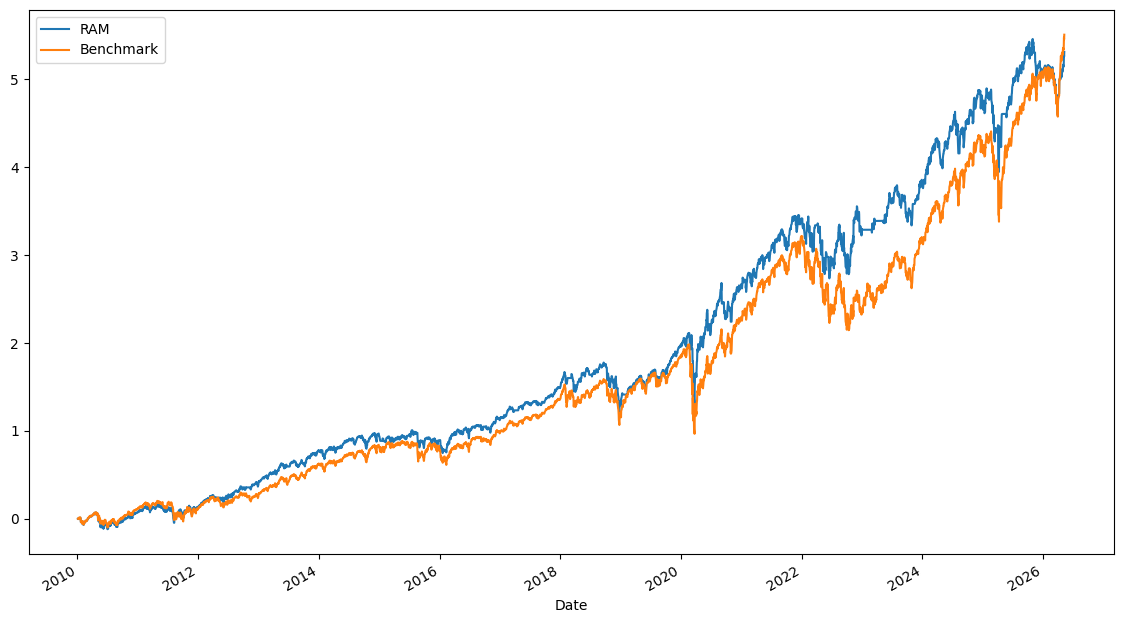

In [7]:
all_backtests = []

for i in range(2010, 2027):

    backtest_df = backtest_func(data, i, optimization_params)

    backtest_df['Date'] = pd.to_datetime(backtest_df['Date'])

    backtest_year = backtest_df[backtest_df['Date'].dt.year == i].copy()
    all_backtests.append(backtest_year)

    del backtest_df

backtest_df = pd.concat(all_backtests, axis=0).sort_values('Date').reset_index(drop=True)

data_plot = backtest_df[(backtest_df['Date'] > f'{2010}-01-01') & (backtest_df['Date'] < f'{2027}-01-01')]

data_plot['r_p'].iloc[0] = 0
data_plot['r_m'].iloc[0] = 0

data_plot['RAM'] = (data_plot['r_p'] + 1).cumprod() - 1
data_plot['Benchmark'] = (data_plot['r_m'] + 1).cumprod() - 1

fig, ax = plt.subplots(figsize=[14, 8])
data_plot.set_index('Date')[['RAM', 'Benchmark']].plot(ax=ax)
plt.savefig(f'backtest/backtest.png', dpi=100, bbox_inches='tight')
plt.show()

r_f = yf.download(['^IRX'], progress=False, auto_adjust=False, start='1990-01-01', multi_level_index=False)['Close'].reset_index().rename(columns={'Close':'r_f'})
r_f['r_f'] = (1 + r_f['r_f'] / 100) ** (1/365) - 1

eval_data = backtest_df[['Date', 'r_p', 'r_m', 'Close']].copy()

eval_data['Date'] = eval_data['Date'].astype('datetime64[s]')
r_f['Date'] = r_f['Date'].astype('datetime64[s]')

eval_data = pd.merge_asof(eval_data, r_f, on='Date', direction='nearest').dropna()
eval_data.to_csv(f'backtest/portfolio.csv', index=False)

stats = evaluate_strategy(eval_data, freq=252)
stats.to_csv(f'backtest/backtest.csv', index=True)